# Born Ready (to Deliver)
## Why do we have so many ready-to-deliver delays?

**Period:** 2026-03-06 to 2026-03-13

**Goal:** Investigate every RTD delay this week. Understand which delay reasons correlate with which critical blockers, and whether the system is failing to act on delivery-stage blockers.

## 1. What is Ready to Deliver?

The car lifecycle state machine (`update-car-lifecycle-state.ts`) transitions cars through:

```
ORDERED → PRODUCED → ARRIVED_FROM_SUPPLIER → TECH_PREPARATION_DONE → READY_TO_DELIVER → IN_SUBSCRIPTION → RETURNED
```

### RTD Transition Logic (lines 121–140)

```typescript
// transition from technical prep done -> ready to deliver
if (
  newStatus === CarStatus.TECH_PREPARATION_DONE &&
  car.registrationData?.status === RegistrationStatus.REGISTERED
) {
  newStatus = CarStatus.READY_TO_DELIVER;
}
```

**Two conditions, that's it:**
1. Car is in `TECH_PREPARATION_DONE` (requires: correct tires mounted + papers received + PDI done)
2. Registration status is `REGISTERED`

**No blocker checks.** No delivery validation. No compound verification.

### Why this matters

Moving to RTD triggers customer-facing handover date assignment. But delivery-stage blockers can still be active:

| Delivery-stage blocker | Critical threshold | What it means |
|---|---|---|
| `sa_number_missing` | 5 days before handover | SA number not yet issued |
| `missing_delivery` | 3 days | No delivery ride posted |
| `deposit_not_paid` | 4 days | Customer hasn't paid deposit |
| `car_at_wrong_compound` | 10 days | Car not at delivery compound |
| `subscription_missing` | 5 days | No subscription linked |
| `registration_missing` | 5 days | Registration not complete |
| `mismatch_terms_registration` | always critical | Gewerblich registration with <12mo term |
| `wrong_insurance` | 7 days | Insurance not ready for delivery |
| `pickup_too_soon` | always critical | Pickup scheduled before car is ready |

These blockers exist but **do not trigger automatic delivery rescheduling**. The car sits with a customer-facing date while critical prep is incomplete.

## 2. RTD Delays This Week: Overview

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from google.cloud import bigquery

# Colab compatibility: authenticate + install if needed
try:
    import google.colab
    google.colab.auth.authenticate_user()
    IN_COLAB = True
    pio.renderers.default = 'colab'
except ImportError:
    IN_COLAB = False
    pio.renderers.default = 'svg'

client = bigquery.Client(project='datawarehouse-304513')

def run_query(query):
    return client.query(query).to_dataframe()

PERIOD_START = '2026-03-06'
PERIOD_END = '2026-03-13'
TITLE_SUFFIX = f'(Week {PERIOD_START} to {PERIOD_END})'
print(f'Analysis period: {PERIOD_START} to {PERIOD_END}')
print(f'Environment: {"Google Colab" if IN_COLAB else "Local"}')

In [2]:
# Load all RTD delay events for the week
delays_query = f"""
WITH date_config AS (
    SELECT DATE('{PERIOD_START}') AS period_start, DATE('{PERIOD_END}') AS period_end
),

customer_facing_delays AS (
    SELECT
        fce.event_id, fce.deal_id, fce.car_id, fce.day_shifted, fce.time_shifted,
        fce.delay_reason, fce.delay_days, fce.previous_handover_date, fce.new_handover_date,
        fce.delay_responsible_team, fce.deviation_in_weeks_at_shift, fce.notes
    FROM `datawarehouse-304513.semantic.fact_car_handover_event` AS fce
    CROSS JOIN date_config
    WHERE fce.day_shifted >= date_config.period_start
      AND fce.day_shifted < date_config.period_end
      AND fce.delay_days > 0
      AND (fce.delay_responsible_team <> 'Non-Ops Delays' OR fce.delay_responsible_team IS NULL)
      AND (NOT fce.is_silent_delay OR fce.is_silent_delay IS NULL)
      AND (fce.deviation_in_weeks_at_shift NOT IN (2, 4) OR fce.deviation_in_weeks_at_shift IS NULL)
      AND fce.deal_id IS NOT NULL
),

delays_with_deal AS (
    SELECT d.*,
        dim.reservation_token, dim.subscribed_to, dim.handover_type,
        CASE WHEN dim.subscribed_to IN ('swap_same_day','swap_different_day') THEN TRUE ELSE FALSE END AS is_part_of_swap
    FROM customer_facing_delays d
    LEFT JOIN `datawarehouse-304513.semantic.dim_deal` dim ON d.deal_id = dim.deal_id
),

car_events_at_shift AS (
    SELECT car_id, event_timestamp,
        LOWER(TRIM(COALESCE(status, ''))) AS car_lifecycle_status,
        actor AS shift_actor
    FROM `datawarehouse-304513.il.il_green_dragon_car_events`
    WHERE name = 'car_reservation_handover_shifted'
),

delays_ready_to_deliver AS (
    SELECT d.event_id, d.deal_id, d.car_id, d.day_shifted, d.time_shifted,
        d.delay_reason, d.delay_days, d.previous_handover_date, d.new_handover_date,
        d.delay_responsible_team, d.deviation_in_weeks_at_shift, d.notes,
        d.reservation_token, d.subscribed_to, d.handover_type, d.is_part_of_swap,
        ce.shift_actor AS actor
    FROM delays_with_deal d
    INNER JOIN car_events_at_shift ce
        ON d.car_id = ce.car_id AND d.time_shifted = ce.event_timestamp
    WHERE ce.car_lifecycle_status = 'ready_to_deliver'
),

delays_with_car AS (
    SELECT d.*,
        COALESCE(c.brand_name, '(no car)') AS car_brand,
        COALESCE(c.infleeting_compound, '(none)') AS compound,
        c.license_plate
    FROM delays_ready_to_deliver d
    LEFT JOIN `datawarehouse-304513.semantic.dim_car` c ON d.car_id = c.car_id
),

delays_with_dri AS (
    SELECT d.*,
        COALESCE(fjc.ops_infleeting_dri__atgd_car_ops_de, '(none)') AS infleeting_dri
    FROM delays_with_car d
    LEFT JOIN `datawarehouse-304513.data_products_de.full_joined_cars` fjc ON d.car_id = fjc.finn_car_id
),

delays_with_customer_type AS (
    SELECT d.*,
        sub.customer_type__gdhsndb_subscription_global AS customer_type
    FROM delays_with_dri d
    LEFT JOIN `datawarehouse-304513.data_products_de.full_joined_subscriptions_de` sub
        ON CAST(d.deal_id AS STRING) = CAST(sub.subscription_id__hsndb_subscription_global AS STRING)
)

SELECT
    event_id,
    deal_id AS subscription_id,
    car_id,
    customer_type,
    handover_type,
    CASE
        WHEN handover_type = 'SELF_PICKUP' THEN 'Finn Station pickup'
        WHEN handover_type = 'DROPOFF' THEN 'Home delivery'
        ELSE COALESCE(handover_type, '(unknown)')
    END AS pickup_or_home_delivery,
    previous_handover_date,
    new_handover_date,
    delay_days AS number_of_days_delayed,
    DATE_DIFF(previous_handover_date, day_shifted, DAY) AS days_between_shift_and_previous_handover,
    actor AS handover_shift_actor,
    car_brand,
    infleeting_dri,
    compound,
    is_part_of_swap,
    subscribed_to,
    license_plate,
    delay_reason,
    delay_responsible_team,
    day_shifted AS day_of_shift,
    time_shifted AS time_of_shift,
    deviation_in_weeks_at_shift,
    notes,
    reservation_token
FROM delays_with_customer_type
ORDER BY day_shifted DESC, time_shifted DESC, event_id
"""

df = run_query(delays_query)
print(f'Loaded {len(df)} RTD delay events')

Loaded 310 RTD delay events


/Users/jan.heiselbetz/venvs/jupyter-py313/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning:

BigQuery Storage module not found, fetch data with the REST endpoint instead.



In [3]:
# Summary stats
n_events = len(df)
n_cars = df['car_id'].nunique()
n_subs = df['subscription_id'].nunique()
total_delay_days = df['number_of_days_delayed'].sum()
median_delay = df['number_of_days_delayed'].median()

print(f'=== RTD Delay Overview {TITLE_SUFFIX} ===')
print(f'Total delay events:       {n_events}')
print(f'Unique cars:              {n_cars}')
print(f'Unique subscriptions:     {n_subs}')
print(f'Total delay days:         {total_delay_days}')
print(f'Median delay (days):      {median_delay}')

=== RTD Delay Overview (Week 2026-03-06 to 2026-03-13) ===
Total delay events:       310
Unique cars:              296
Unique subscriptions:     296
Total delay days:         2471
Median delay (days):      7.0


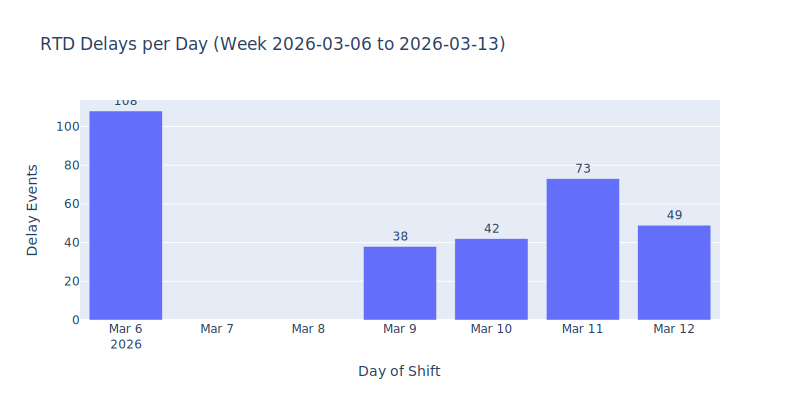

In [4]:
# Daily delay volume
daily = df.groupby('day_of_shift').agg(
    events=('event_id', 'count'),
    cars=('car_id', 'nunique'),
    total_delay_days=('number_of_days_delayed', 'sum')
).reset_index()

fig = px.bar(daily, x='day_of_shift', y='events', text='events',
             title=f'RTD Delays per Day {TITLE_SUFFIX}',
             labels={'day_of_shift': 'Day of Shift', 'events': 'Delay Events'})
fig.update_traces(textposition='outside')
fig.update_layout(height=400, width=800)
fig.show()

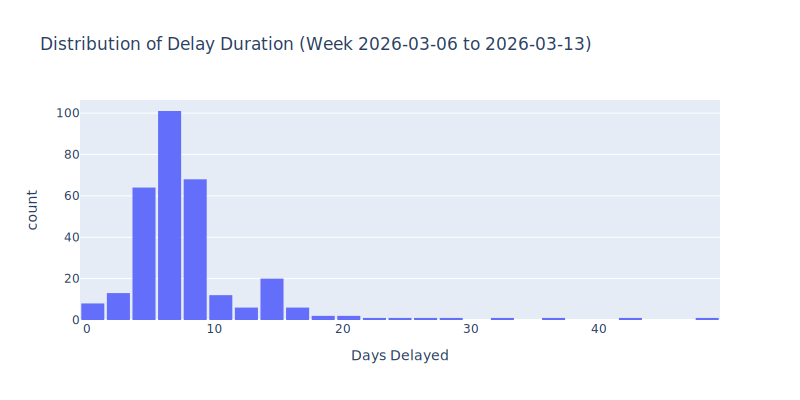

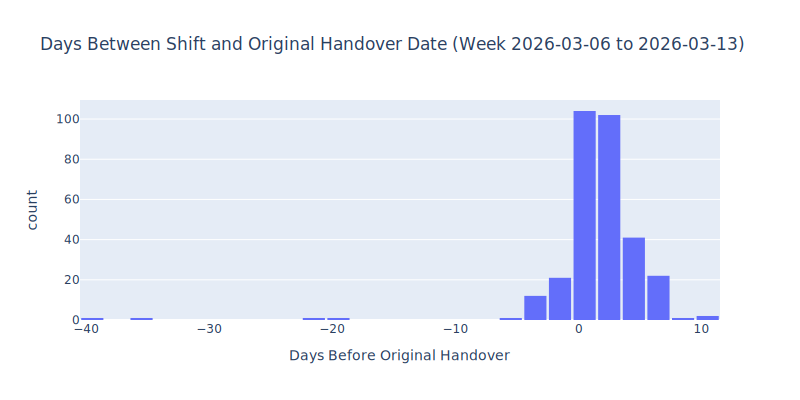

In [5]:
# Delay days distribution
fig = px.histogram(df, x='number_of_days_delayed', nbins=30,
                   title=f'Distribution of Delay Duration {TITLE_SUFFIX}',
                   labels={'number_of_days_delayed': 'Days Delayed', 'count': 'Events'})
fig.update_layout(height=400, width=800, bargap=0.1)
fig.show()

# Days between shift and previous handover (how far in advance the shift happened)
fig2 = px.histogram(df, x='days_between_shift_and_previous_handover', nbins=30,
                    title=f'Days Between Shift and Original Handover Date {TITLE_SUFFIX}',
                    labels={'days_between_shift_and_previous_handover': 'Days Before Original Handover', 'count': 'Events'})
fig2.update_layout(height=400, width=800, bargap=0.1)
fig2.show()

## 3. Delay Reasons & Their Critical Blockers

For each delay reason, we check which blockers were **still unresolved at the time of the shift** — i.e., blockers that had been created before the shift but not yet resolved/deleted by that point. These are the blockers that were critical when the delay happened.

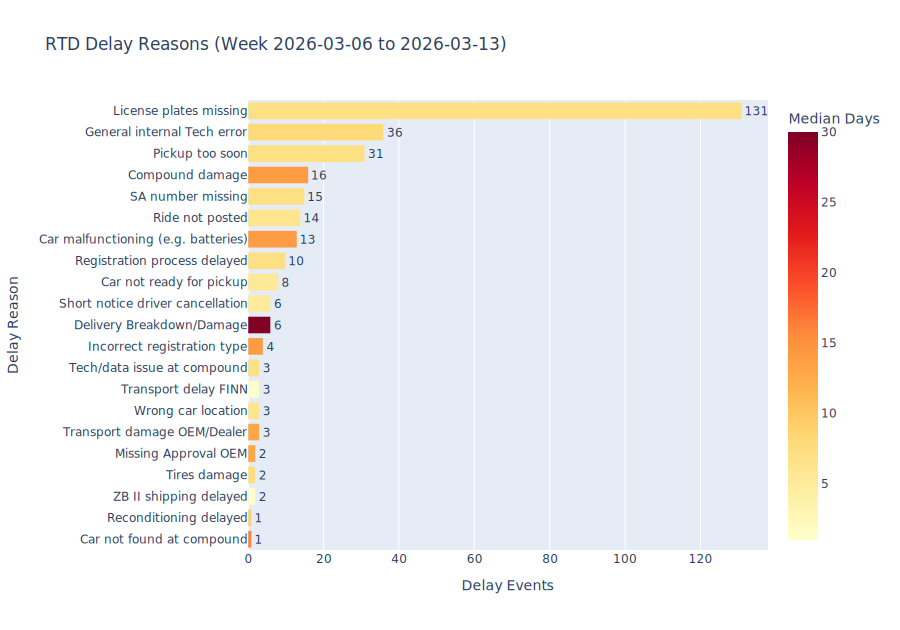


Delay Reason                                   Events   Cars   Med  Total d
---------------------------------------------------------------------------
License plates missing                            131    126     7      832
General internal Tech error                        36     36     8      326
Pickup too soon                                    31     31     7      252
Compound damage                                    16     16    14      219
SA number missing                                  15     15     7       94
Ride not posted                                    14     14     6       79
Car malfunctioning (e.g. batteries)                13     13    14      160
Registration process delayed                       10     10     7       70
Car not ready for pickup                            8      7     6       35
Delivery Breakdown/Damage                           6      6    30      173
Short notice driver cancellation                    6      6     5       30
Incorrect r

In [6]:
# Delay reason breakdown
reason_counts = df.groupby('delay_reason').agg(
    events=('event_id', 'count'),
    cars=('car_id', 'nunique'),
    median_delay=('number_of_days_delayed', 'median'),
    total_delay_days=('number_of_days_delayed', 'sum')
).sort_values('events', ascending=False).reset_index()

fig = px.bar(reason_counts, y='delay_reason', x='events', orientation='h',
             text='events', color='median_delay', color_continuous_scale='YlOrRd',
             title=f'RTD Delay Reasons {TITLE_SUFFIX}',
             labels={'events': 'Delay Events', 'delay_reason': 'Delay Reason', 'median_delay': 'Median Days'})
fig.update_traces(textposition='outside')
fig.update_layout(height=max(400, len(reason_counts) * 30), width=900,
                  yaxis={'categoryorder': 'total ascending'})
fig.show()

print(f'\n{"Delay Reason":<45} {"Events":>7} {"Cars":>6} {"Med":>5} {"Total d":>8}')
print('-' * 75)
for _, r in reason_counts.iterrows():
    print(f"{r['delay_reason']:<45} {r['events']:>7} {r['cars']:>6} {r['median_delay']:>5.0f} {r['total_delay_days']:>8.0f}")

In [7]:
# For each delay event, find which blockers were active (unresolved) at the time of the shift
# A blocker is "active at shift time" if created before the shift and not resolved/deleted before or at shift time

car_ids = df['car_id'].unique().tolist()
car_ids_str = ','.join([f"'{c}'" for c in car_ids])

blockers_query = f"""
WITH
shift_events AS (
    SELECT
        event_id, car_id, time_of_shift
    FROM UNNEST([
        {','.join([f"STRUCT('{row.event_id}' AS event_id, '{row.car_id}' AS car_id, TIMESTAMP('{row.time_of_shift}') AS time_of_shift)" for _, row in df.iterrows()])}
    ])
),
blocker_created AS (
    SELECT car_id, blocking_reason, time AS created_time
    FROM `datawarehouse-304513.cars_ops_postgres_public.blockers_events`
    WHERE name = 'blocker_created'
      AND car_id IN ({car_ids_str})
),
blocker_resolved AS (
    SELECT car_id, blocking_reason, time AS resolved_time
    FROM `datawarehouse-304513.cars_ops_postgres_public.blockers_events`
    WHERE name IN ('blocker_resolved', 'blocker_deleted')
      AND car_id IN ({car_ids_str})
),
active_at_shift AS (
    SELECT
        se.event_id, se.car_id, bc.blocking_reason, bc.created_time,
        MIN(br.resolved_time) AS first_resolution_before_shift
    FROM shift_events se
    INNER JOIN blocker_created bc
        ON se.car_id = bc.car_id AND bc.created_time < se.time_of_shift
    LEFT JOIN blocker_resolved br
        ON bc.car_id = br.car_id
        AND bc.blocking_reason = br.blocking_reason
        AND br.resolved_time > bc.created_time
        AND br.resolved_time <= se.time_of_shift
    GROUP BY se.event_id, se.car_id, bc.blocking_reason, bc.created_time
)
SELECT event_id, car_id, blocking_reason
FROM active_at_shift
WHERE first_resolution_before_shift IS NULL
"""

blockers_at_shift = run_query(blockers_query)
print(f'Found {len(blockers_at_shift)} blocker-at-shift records across {blockers_at_shift["event_id"].nunique()} delay events')

Found 212 blocker-at-shift records across 177 delay events


/Users/jan.heiselbetz/venvs/jupyter-py313/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning:

BigQuery Storage module not found, fetch data with the REST endpoint instead.



In [8]:
# Merge blockers with delay events to get delay_reason x blocker matrix
merged = df[['event_id', 'car_id', 'delay_reason']].merge(
    blockers_at_shift[['event_id', 'blocking_reason']],
    on='event_id', how='left'
)

# Events with vs without active blockers
events_with_blockers = merged.dropna(subset=['blocking_reason'])['event_id'].nunique()
events_without_blockers = n_events - events_with_blockers
print(f'Events with at least one active blocker at shift time: {events_with_blockers} ({100*events_with_blockers/n_events:.1f}%)')
print(f'Events with no active blocker at shift time: {events_without_blockers} ({100*events_without_blockers/n_events:.1f}%)')

# Per delay reason: how many had active blockers?
reason_blocker_summary = merged.groupby('delay_reason').agg(
    total_events=('event_id', 'nunique'),
    events_with_blocker=('blocking_reason', lambda x: x.dropna().shape[0] > 0 and merged.loc[x.dropna().index, 'event_id'].nunique() or 0)
).reset_index()
# Recalculate properly
events_with_blocker_per_reason = merged.dropna(subset=['blocking_reason']).groupby('delay_reason')['event_id'].nunique().reset_index()
events_with_blocker_per_reason.columns = ['delay_reason', 'events_with_blocker']
reason_blocker_summary = df.groupby('delay_reason')['event_id'].nunique().reset_index()
reason_blocker_summary.columns = ['delay_reason', 'total_events']
reason_blocker_summary = reason_blocker_summary.merge(events_with_blocker_per_reason, on='delay_reason', how='left')
reason_blocker_summary['events_with_blocker'] = reason_blocker_summary['events_with_blocker'].fillna(0).astype(int)
reason_blocker_summary['pct_with_blocker'] = round(100 * reason_blocker_summary['events_with_blocker'] / reason_blocker_summary['total_events'], 1)
reason_blocker_summary = reason_blocker_summary.sort_values('total_events', ascending=False)

print(f'\n{"Delay Reason":<45} {"Total":>6} {"w/ Blocker":>10} {"%":>6}')
print('-' * 70)
for _, r in reason_blocker_summary.iterrows():
    print(f"{r['delay_reason']:<45} {r['total_events']:>6} {r['events_with_blocker']:>10} {r['pct_with_blocker']:>5.1f}%")

Events with at least one active blocker at shift time: 177 (57.1%)
Events with no active blocker at shift time: 133 (42.9%)

Delay Reason                                   Total w/ Blocker      %
----------------------------------------------------------------------
License plates missing                           131         61  46.6%
General internal Tech error                       36         24  66.7%
Pickup too soon                                   31         22  71.0%
Compound damage                                   16         13  81.2%
SA number missing                                 15         11  73.3%
Ride not posted                                   14          5  35.7%
Car malfunctioning (e.g. batteries)               13          8  61.5%
Registration process delayed                      10          3  30.0%
Car not ready for pickup                           8          5  62.5%
Delivery Breakdown/Damage                          6          4  66.7%
Short notice driver can

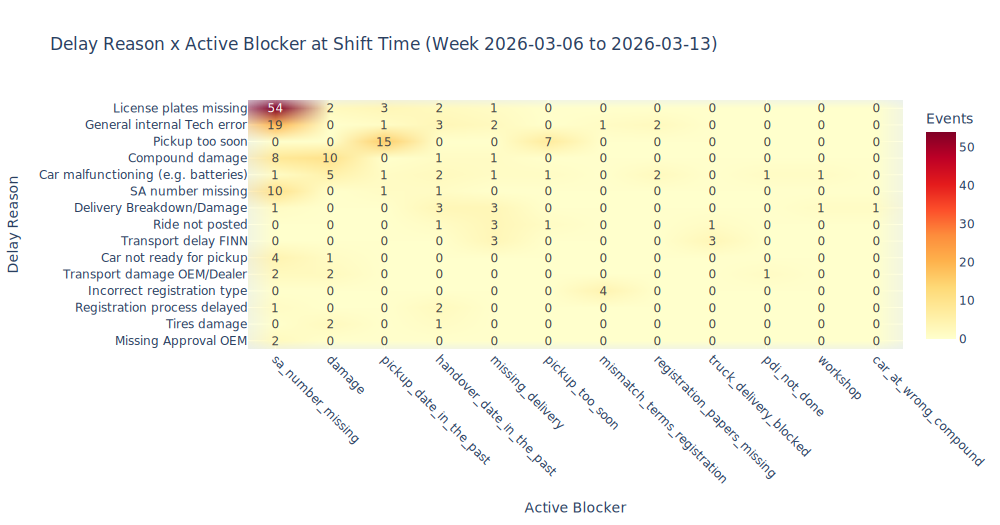

In [9]:
# Reason x Blocker heatmap
reason_blocker_matrix = merged.dropna(subset=['blocking_reason']).groupby(
    ['delay_reason', 'blocking_reason']
)['event_id'].nunique().reset_index()
reason_blocker_matrix.columns = ['delay_reason', 'blocking_reason', 'events']

if len(reason_blocker_matrix) > 0:
    # Pivot for heatmap
    top_reasons = reason_blocker_matrix.groupby('delay_reason')['events'].sum().nlargest(15).index
    top_blockers = reason_blocker_matrix.groupby('blocking_reason')['events'].sum().nlargest(12).index

    heat = reason_blocker_matrix[
        reason_blocker_matrix['delay_reason'].isin(top_reasons) &
        reason_blocker_matrix['blocking_reason'].isin(top_blockers)
    ].pivot_table(index='delay_reason', columns='blocking_reason', values='events', fill_value=0)
    heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]
    heat = heat[heat.sum().sort_values(ascending=False).index]

    fig = px.imshow(
        heat, color_continuous_scale='YlOrRd', text_auto=True, aspect='auto',
        title=f'Delay Reason x Active Blocker at Shift Time {TITLE_SUFFIX}',
        labels=dict(x='Active Blocker', y='Delay Reason', color='Events')
    )
    fig.update_layout(height=max(500, len(heat) * 35), width=1000)
    fig.update_xaxes(tickangle=45)
    fig.show()
else:
    print('No blocker data to show in heatmap.')

## 4. Deep Dives

### 4a. Pickup Too Soon

These are RTD cars where the delay reason involves pickup timing — the car is technically RTD but the pickup date is too close or already past. Since we're already filtered to RTD-status cars, these are infleeting PTS (no return/defleeting noise).

In [10]:
# PTS delay events
pts_keywords = ['pickup_too_soon', 'pickup too soon', 'Pickup too soon']
pts_df = df[df['delay_reason'].str.lower().str.contains('pickup', na=False)].copy()

if len(pts_df) == 0:
    # Also check for the exact reason string
    pts_df = df[df['delay_reason'].str.lower().isin([r.lower() for r in pts_keywords])].copy()

print(f'PTS-related delay events: {len(pts_df)} ({100*len(pts_df)/n_events:.1f}% of all RTD delays)')

if len(pts_df) > 0:
    # Get their active blockers at shift time
    pts_blockers = merged[merged['event_id'].isin(pts_df['event_id'])].dropna(subset=['blocking_reason'])
    pts_blocker_counts = pts_blockers.groupby('blocking_reason')['event_id'].nunique().sort_values(ascending=False)

    print(f'\nActive blockers on PTS cars at shift time:')
    print(f'{"Blocker":<40} {"Events":>7}')
    print('-' * 50)
    for blocker, count in pts_blocker_counts.items():
        print(f'{blocker:<40} {count:>7}')

    # Days between shift and original handover for PTS
    print(f'\nDays between shift and original handover (PTS):')
    print(f'  Median: {pts_df["days_between_shift_and_previous_handover"].median():.0f}')
    print(f'  Mean:   {pts_df["days_between_shift_and_previous_handover"].mean():.1f}')
    print(f'  Min:    {pts_df["days_between_shift_and_previous_handover"].min()}')
    print(f'  Max:    {pts_df["days_between_shift_and_previous_handover"].max()}')
else:
    print('No PTS delay events found. Check delay_reason values:')
    print(df['delay_reason'].unique())

PTS-related delay events: 39 (12.6% of all RTD delays)

Active blockers on PTS cars at shift time:
Blocker                                   Events
--------------------------------------------------
pickup_date_in_the_past                       15
pickup_too_soon                                7
sa_number_missing                              4
damage                                         1

Days between shift and original handover (PTS):
  Median: 0
  Mean:   0.1
  Min:    -4
  Max:    5


In [11]:
# Full detail table: every PTS event
if len(pts_df) > 0:
    # Add active blockers as comma-separated string
    pts_event_blockers = pts_blockers.groupby('event_id')['blocking_reason'].apply(', '.join).reset_index()
    pts_event_blockers.columns = ['event_id', 'active_blockers_at_shift']

    pts_detail = pts_df.merge(pts_event_blockers, on='event_id', how='left')
    pts_detail['active_blockers_at_shift'] = pts_detail['active_blockers_at_shift'].fillna('(none)')

    display_cols = ['car_id', 'subscription_id', 'car_brand', 'compound', 'license_plate',
                    'previous_handover_date', 'new_handover_date', 'number_of_days_delayed',
                    'days_between_shift_and_previous_handover', 'active_blockers_at_shift',
                    'handover_shift_actor', 'notes']
    print(f'Full PTS detail table ({len(pts_detail)} events):')
    pts_detail[display_cols]
else:
    print('No PTS events to display.')

Full PTS detail table (39 events):


### 4b. Internal Tech Errors

Tech/system errors — issues caused by internal tooling failures (iKFZ outages, system bugs, etc.).

In [12]:
# Internal tech error delay events
# Common patterns: "internal tech error", "tech error", "system error", "iKFZ", "technical"
tech_keywords = ['tech', 'system', 'internal', 'ikfz', 'technical', 'bug', 'error']
tech_df = df[df['delay_reason'].str.lower().apply(
    lambda x: any(kw in str(x).lower() for kw in tech_keywords) if pd.notna(x) else False
)].copy()

# Also check notes for tech-related content
tech_notes_df = df[~df.index.isin(tech_df.index) & df['notes'].str.lower().apply(
    lambda x: any(kw in str(x).lower() for kw in ['ikfz', 'tech error', 'system', 'bug']) if pd.notna(x) else False
)].copy()

print(f'Tech error delay events (by delay_reason): {len(tech_df)}')
if len(tech_df) > 0:
    print(f'  Delay reasons: {tech_df["delay_reason"].value_counts().to_dict()}')

print(f'\nAdditional events with tech-related notes: {len(tech_notes_df)}')
if len(tech_notes_df) > 0:
    print(f'  Delay reasons: {tech_notes_df["delay_reason"].value_counts().to_dict()}')

# Combine
all_tech = pd.concat([tech_df, tech_notes_df]).drop_duplicates(subset='event_id')
print(f'\nTotal tech-related events: {len(all_tech)}')

Tech error delay events (by delay_reason): 39
  Delay reasons: {'General internal Tech error': 36, 'Tech/data issue at compound': 3}

Additional events with tech-related notes: 0

Total tech-related events: 39


In [13]:
# Full detail table: every tech error event
if len(all_tech) > 0:
    # Add active blockers
    tech_event_blockers = merged[merged['event_id'].isin(all_tech['event_id'])].dropna(
        subset=['blocking_reason']
    ).groupby('event_id')['blocking_reason'].apply(', '.join).reset_index()
    tech_event_blockers.columns = ['event_id', 'active_blockers_at_shift']

    tech_detail = all_tech.merge(tech_event_blockers, on='event_id', how='left')
    tech_detail['active_blockers_at_shift'] = tech_detail['active_blockers_at_shift'].fillna('(none)')

    # Categorize by pattern
    def categorize_tech(row):
        reason = str(row['delay_reason']).lower()
        notes = str(row['notes']).lower()
        combined = reason + ' ' + notes
        if 'ikfz' in combined or 'registration' in combined or 'license' in combined or 'plate' in combined:
            return 'Registration / iKFZ'
        elif 'delivery' in combined or 'ride' in combined:
            return 'Delivery system'
        else:
            return 'Other / unclassified'

    tech_detail['tech_category'] = tech_detail.apply(categorize_tech, axis=1)

    print(f'Tech error categories:')
    print(tech_detail['tech_category'].value_counts().to_string())
    print()

    # Actor distribution
    print(f'Actors (system vs human):')
    print(tech_detail['handover_shift_actor'].value_counts().to_string())
    print()

    display_cols = ['car_id', 'subscription_id', 'delay_reason', 'tech_category',
                    'car_brand', 'compound', 'number_of_days_delayed',
                    'handover_shift_actor', 'active_blockers_at_shift', 'notes']
    print(f'Full tech error detail table ({len(tech_detail)} events):')
    tech_detail[display_cols]
else:
    print('No tech error events found.')
    print(f'All delay reasons in dataset: {sorted(df["delay_reason"].dropna().unique())}')

Tech error categories:
tech_category
Other / unclassified    39

Actors (system vs human):
handover_shift_actor
natalie.hafner@finn.com                                                                  12
teresa.hoerger@finn.com                                                                   5
stefan.schenkl@finn.com                                                                   4
sebastian.obermeier@finn.com                                                              4
https://finn.integromat.cloud/4/scenarios/20079/logs/ca604dd8da60469ab1dc789dcbc131e2     3
https://finn.integromat.cloud/4/scenarios/20079/logs/8cb6b87de6094e408c5781899dba1aad     3
https://finn.integromat.cloud/4/scenarios/20079/logs/51e330f981ac45d3b95a57f3145c4d40     3
jessica.zinz@finn.com                                                                     2
https://finn.integromat.cloud/4/scenarios/23316/logs/896b7f28629740698c657fb230e34d9f     1
maria.kammel@finn.com                                       

## 5. Operational Cuts

Absolute counts — this is a single-week snapshot for prioritization, not a rate analysis.

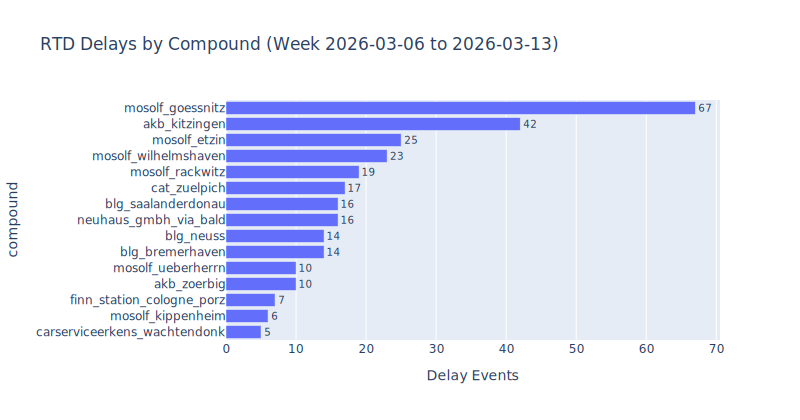

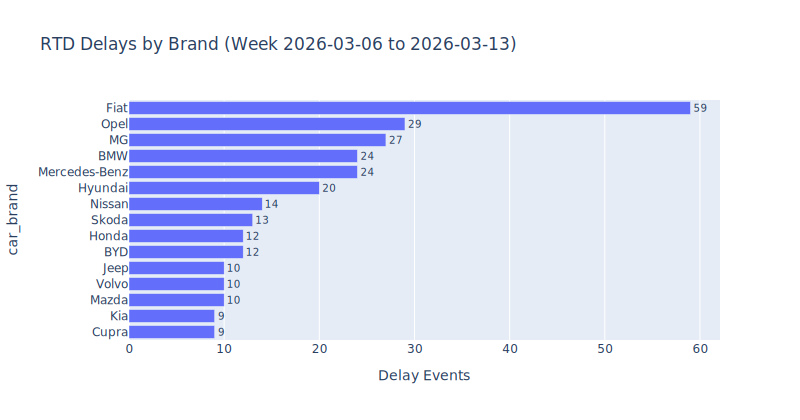

In [14]:
from plotly.subplots import make_subplots

def bar_chart(data, col, title):
    counts = data.groupby(col).agg(events=('event_id', 'count')).sort_values('events', ascending=False).reset_index()
    fig = px.bar(counts.head(15), y=col, x='events', orientation='h', text='events',
                 title=f'{title} {TITLE_SUFFIX}',
                 labels={'events': 'Delay Events', col: col})
    fig.update_traces(textposition='outside')
    fig.update_layout(height=max(350, len(counts.head(15)) * 28), width=800,
                      yaxis={'categoryorder': 'total ascending'})
    fig.show()

# By compound
bar_chart(df, 'compound', 'RTD Delays by Compound')

# By brand
bar_chart(df, 'car_brand', 'RTD Delays by Brand')

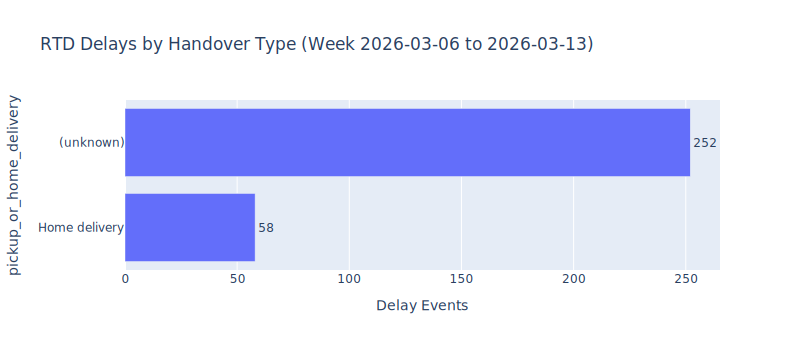

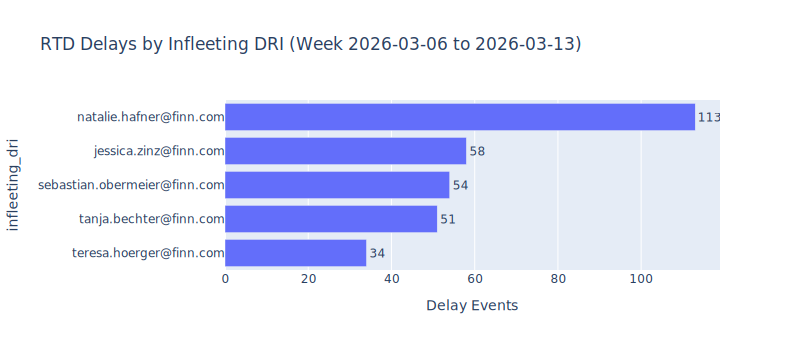

In [15]:
# By handover type (pickup vs home delivery)
bar_chart(df, 'pickup_or_home_delivery', 'RTD Delays by Handover Type')

# By infleeting DRI
bar_chart(df, 'infleeting_dri', 'RTD Delays by Infleeting DRI')

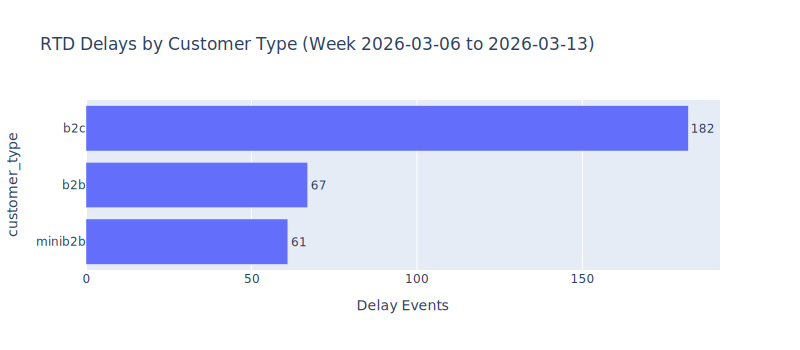

Swap vs Non-swap:
  Non-swap: 310 (100.0%)


In [16]:
# By customer type
bar_chart(df, 'customer_type', 'RTD Delays by Customer Type')

# Swap flag
swap_counts = df.groupby('is_part_of_swap').agg(events=('event_id', 'count')).reset_index()
swap_counts['label'] = swap_counts['is_part_of_swap'].map({True: 'Swap', False: 'Non-swap'})
total = swap_counts['events'].sum()
print(f'Swap vs Non-swap:')
for _, r in swap_counts.iterrows():
    print(f"  {r['label']}: {r['events']} ({100*r['events']/total:.1f}%)")

## 6. Verdict & Summary

_Fill in after running the notebook with real data._

### Key Numbers

- **Total RTD delay events this week:**
- **Unique cars affected:**
- **Total delay days:**
- **% with active blockers at shift time:**

### Top Delay Reasons

1.
2.
3.

### Top Active Blockers at Shift Time

1.
2.
3.

### Pickup Too Soon

- PTS events:
- Most common co-active blockers:

### Internal Tech Errors

- Tech error events:
- Categories:

### Does this week confirm the pattern?

The investigation report found that delivery-stage blockers (SA number, deposit, wrong compound, missing delivery) don't trigger automatic rescheduling. Cars sit in RTD with a customer-facing date while critical blockers remain unresolved.

**This week's evidence:**
-
-
-

### Actionable Takeaways

1.
2.
3.